In [202]:
##############
## INITIATE ##
##############

## Note: this could be moved to pawmil-V1 (as this is the final step of the pipeline)

## Imports
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap


## Figure parameters
plt.rcParams['figure.dpi'] = 300
figsize = (14,5)
custom_params = {'axes.spines.right': False, 
                 'axes.spines.top': False, 
                 'axes.facecolor':'whitesmoke'
                }
sns.set_theme(style="ticks", rc=custom_params)

#
###

In [215]:

def visualise_scores(TARGET_SLIDE, FOLDER_NAME, MODEL_NAME, LABEL, PT_WSIs):
    
    ## Input files
    ptf_identifiers = f"/Volumes/Elements/BDI/projects/GSG/outputs/o1_extracted_glands/{FOLDER_NAME}/{TARGET_SLIDE}_identifiers.npy"
    ptf_gland_polygons = f"/Volumes/Elements/BDI/projects/GSG/outputs/o1_extracted_glands/{FOLDER_NAME}/{TARGET_SLIDE}_polygons.pkl"
    ptf_cluster_labels = f"/Volumes/Elements/BDI/projects/GSG/outputs/o3_mil/{FOLDER_NAME}/{MODEL_NAME}/aggregator_pawmil_1000/singletask-{LABEL}/predictions/tab_summary_predictions.csv"
    # ptf_cluster_labels = f"/Users/user/Documents/projects/GSG/outputs/o2_embeddings/{FOLDER_NAME}/{MODEL_NAME}/image_identifiers_and_predicted_clusters.csv"
        
    #########################################
    ## LOAD AND FORMAT LABELS AND POLYGONS ##
    #########################################
    
    ## Load identifiers
    identifiers = np.load(ptf_identifiers)
    
    ## Load the predicted cluster labels CSV
    df_clusters = pd.read_csv(ptf_cluster_labels)
    
    ## Extract slide identifier from 'filename' column
    df_clusters["slide_id"] = df_clusters["image_filenames"].str.split("__").str[0]
    
    ## Filter for the target slide
    df_target_slide = df_clusters[df_clusters["slide_id"] == TARGET_SLIDE]
    
    ## Load the gland polygons (pickled list of coordinates)
    with open(ptf_gland_polygons, "rb") as f:
        gland_polygons = pickle.load(f)
    
    ## Check for consistency
    if len(df_target_slide) != len(gland_polygons):
        print(f"Warning: Number of cluster labels ({len(df_target_slide)}) and polygons ({len(gland_polygons)}) do not match.")
    
    #
    ###
    
    ########################################
    ## ALIGN POLYGONS WITH CLUSTER LABELS ##
    ########################################
    
    # Remove "_mask_both" suffix from cluster filenames for comparison
    df_clusters["clean_filename"] = df_clusters["image_filenames"].str.replace("_raw", "", regex=False)
    
    # Convert identifiers to comparable format
    identifier_list = [os.path.basename(idf) for idf in identifiers]
    
    # Reorder df_clusters based on identifier order
    df_target_slide = df_clusters.set_index("clean_filename").loc[identifier_list].reset_index()
    
    # Verify alignment
    if not np.array_equal(df_target_slide["clean_filename"].values, identifier_list):
        print("Warning: Identifiers and cluster labels are still misaligned!")
    else:
        print("Identifiers successfully aligned with cluster labels.")
    
    ## Extract cluster labels
    scores = df_target_slide["scores"].values
    
    #
    ###

    ###############
    ## VISUALISE ##
    ###############

    """
    ## Determine the image size (max coordinates to define canvas size)
    all_pixels = np.concatenate(gland_polygons, axis=0)  # Flatten all points
    max_x, max_y = np.max(all_pixels, axis=0)  # Get max dimensions
    canvas_size = (max_y + 1, max_x + 1)  # Ensure proper shape (rows, cols)
    
    ## Create a blank image (black background)
    canvas = np.zeros(canvas_size, dtype=np.uint8)
    
    ## Assign colors to each object
    for pixel_coords, scores_ in zip(gland_polygons, scores):
        pixel_array = np.array(pixel_coords)
        canvas[pixel_array[:, 1], pixel_array[:, 0]] = scores_ + 2  # Assign cluster label to pixels
    
    ## Display the canvas with a colormap
    plt.figure(figsize=(5, 4))
    plt.imshow(canvas.T, cmap="jet", interpolation="nearest")
    plt.colorbar(label="Scores", ticks=[-1,0,1])
    # plt.title(f"Gland-level Predictions {TARGET_SLIDE}")
    plt.axis("off")  # Hide axis for better visualization
    plt.show()
    """
    
    
    # Custom blue → gold → red colormap
    custom_cmap = LinearSegmentedColormap.from_list("blue_gold_red", ["black", "royalblue", "gray", "red"])
    
    # Map original scores (-1, 0, 1) to display values (e.g., 1, 2, 3)
    score_display_map = {-1: 1, 0: 2, 1: 3}
    
    # Canvas creation (same as before)
    all_pixels = np.concatenate(gland_polygons, axis=0)
    max_x, max_y = np.max(all_pixels, axis=0)
    canvas_size = (max_y + 1, max_x + 1)
    canvas = np.zeros(canvas_size, dtype=np.uint8)
    
    for pixel_coords, score in zip(gland_polygons, scores):
        pixel_array = np.array(pixel_coords)
        display_val = score_display_map[score]
        canvas[pixel_array[:, 1], pixel_array[:, 0]] = display_val
    
    # Set up the norm and ticks for correct colorbar display
    bounds = [0.0, 0.5, 1.5, 2.5, 3.5]  # Define edges between -1, 0, 1
    norm = BoundaryNorm(bounds, custom_cmap.N)
    tick_labels = [-2, -1, 0, 1]
    
    # Plot
    plt.figure(figsize=(5, 4))
    img = plt.imshow(canvas.T, cmap=custom_cmap, norm=norm, interpolation="nearest")
    cbar = plt.colorbar(img, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(tick_labels)  # Map to original score labels
    cbar.set_label("Scores")
    plt.axis("off")
    plt.show()
    
    import openslide
    from PIL import Image
    
    # Path to the .svs slide
    ptf_slide = f"{PT_WSIs}/{TARGET_SLIDE}"
    print(ptf_slide)
    
    # Open the slide
    slide = openslide.OpenSlide(ptf_slide)
    
    # Choose a low-resolution level (e.g., last level for an overview)
    level = slide.level_count - 1
    slide_thumbnail = slide.read_region((0, 0), level, slide.level_dimensions[level]).convert("RGB")
        
    # Display side-by-side
    plt.figure(figsize=(5, 4))    
    plt.imshow(slide_thumbnail)
    # plt.set_title("Original Slide")
    plt.axis("off")    
    plt.tight_layout()
    plt.show()    


    """
    ## OVERLAY ##
    from PIL import Image
    import openslide
    from matplotlib import cm    
    
    DOWNSAMPLE = 6  # Example downsampling factor
    
    # Path to the .svs slide
    ptf_slide = f"{PT_WSIs}/{TARGET_SLIDE}"
    slide = openslide.OpenSlide(ptf_slide)
    
    # Read region at a low level (e.g., level N) and determine actual downsample
    level = slide.level_count - 1
    slide_thumb = slide.read_region((0, 0), level, slide.level_dimensions[level]).convert("RGB")
    
    # Resize canvas to match thumbnail size
    # Note: canvas shape is (rows, cols) = (H, W), but PIL expects (W, H)
    canvas_resized = Image.fromarray(canvas.T).resize(slide.level_dimensions[level], resample=Image.NEAREST)
    
    # Convert to RGBA heatmap using your colormap
    colormap = cm.get_cmap(custom_cmap)
    canvas_rgba = colormap(norm(np.array(canvas_resized)))  # RGBA values in [0, 1]
    canvas_rgba = (canvas_rgba * 255).astype(np.uint8)
    canvas_rgba_img = Image.fromarray(canvas_rgba, mode="RGBA")
    
    # Set transparency (e.g., alpha = 100 out of 255) where mask is not background
    alpha_mask = (np.array(canvas_resized) > 0).astype(np.uint8) * 100
    canvas_rgba_img.putalpha(Image.fromarray(alpha_mask))
    
    # Convert slide thumbnail to RGBA for compositing
    slide_rgba = slide_thumb.convert("RGBA")
    
    # Composite overlay onto the original slide
    overlayed_img = Image.alpha_composite(slide_rgba, canvas_rgba_img)
    
    # Show result
    plt.figure(figsize=(10, 8))
    plt.imshow(overlayed_img)
    plt.title("Overlay: Gland Predictions on Slide")
    plt.axis("off")
    plt.show()
    """
        
    #
    ###

#
###

Identifiers successfully aligned with cluster labels.


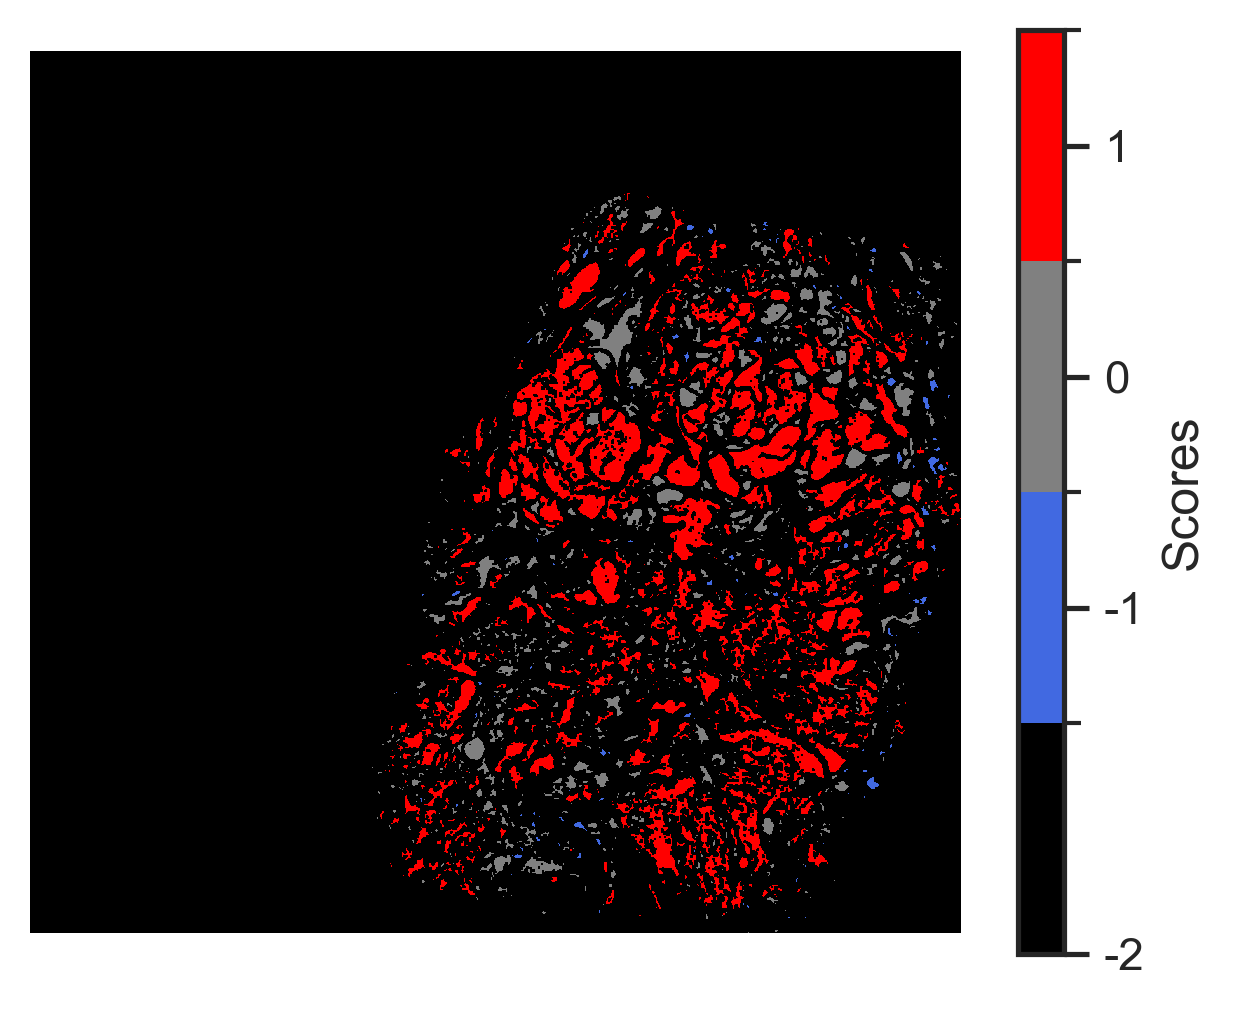

/Volumes/Elements/BDI/datasets/TCGA/images/svs/TCGA-V1-A8WV-01A_1.svs


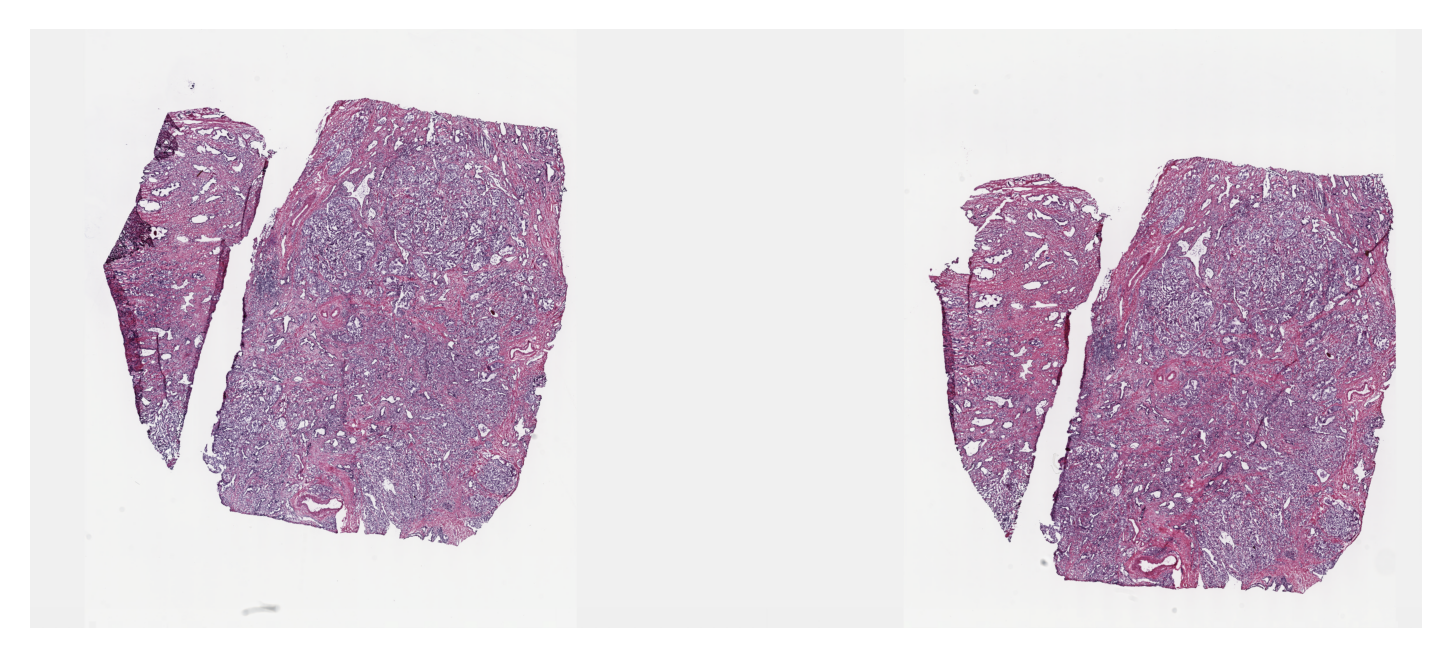

Identifiers successfully aligned with cluster labels.


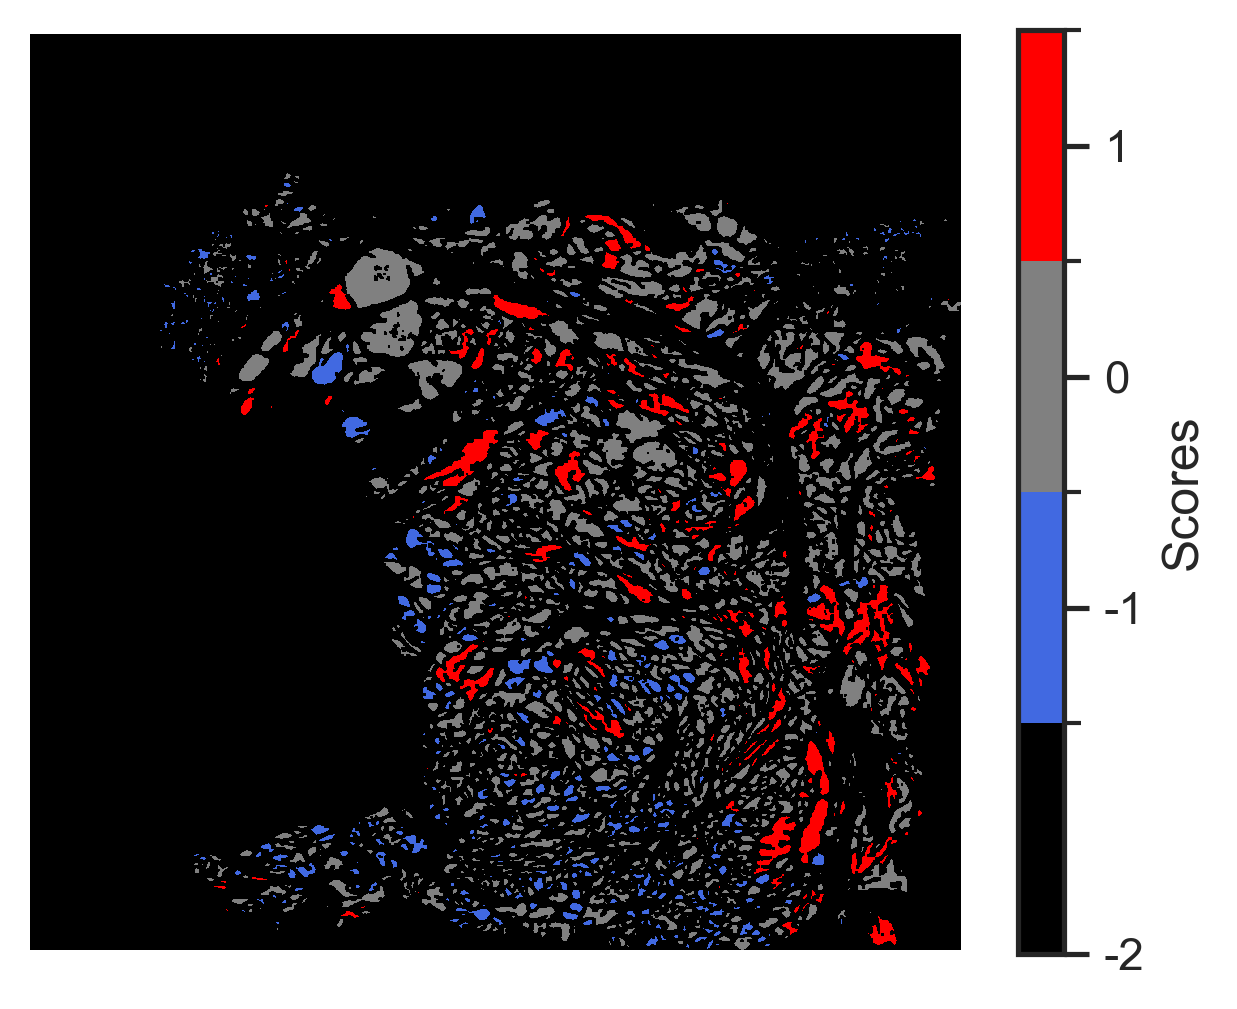

/Volumes/Elements/BDI/datasets/TCGA/images/svs/TCGA-EJ-7218-01B_1.svs


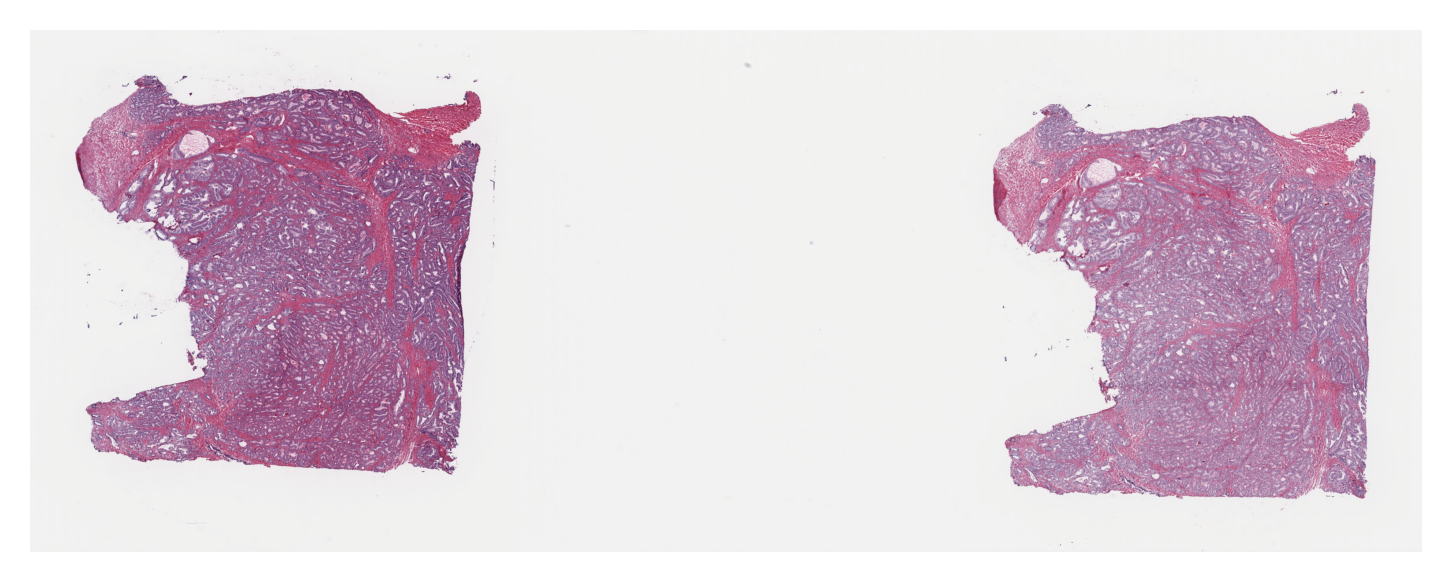

Identifiers successfully aligned with cluster labels.


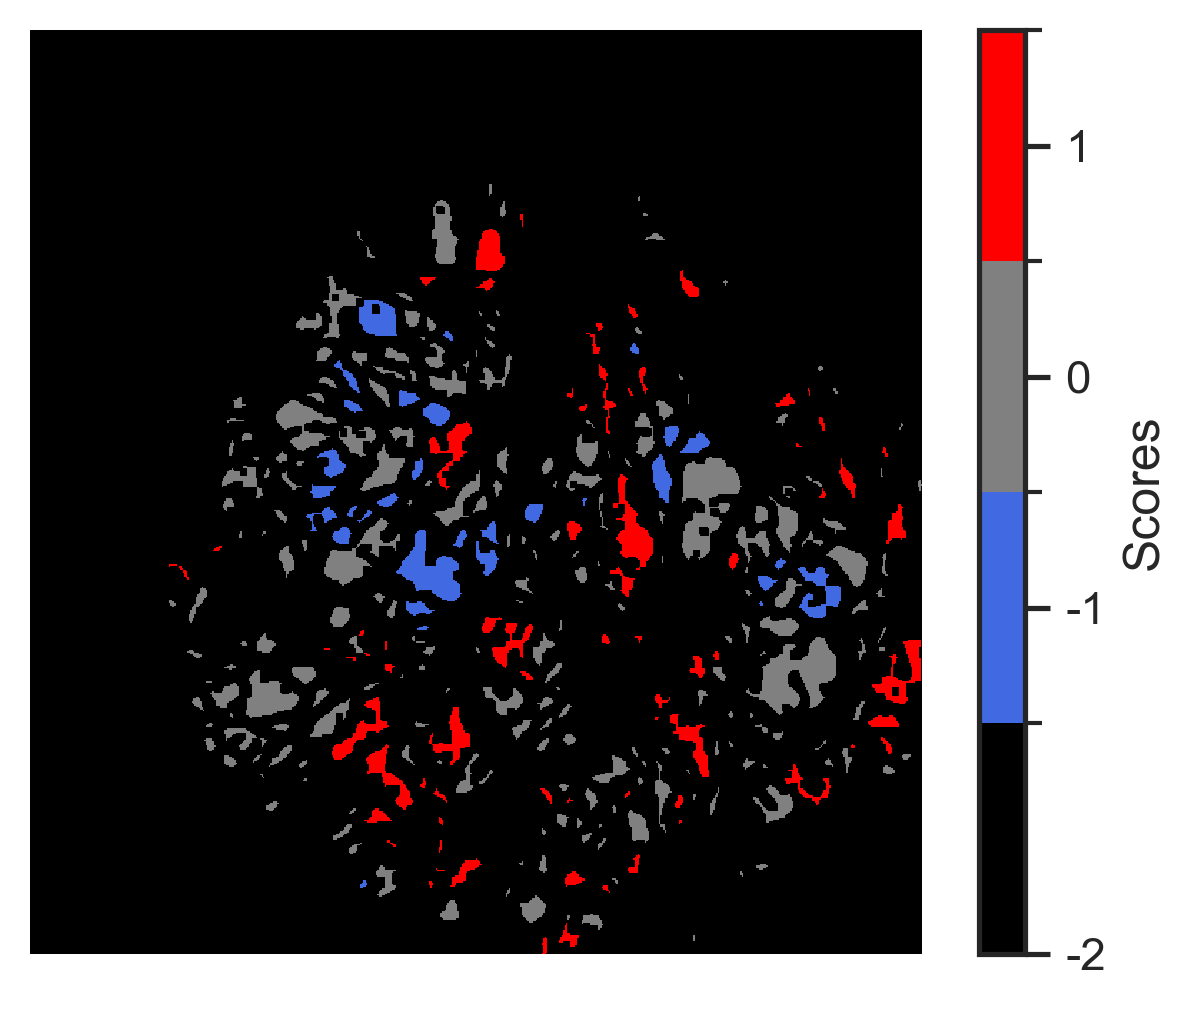

/Volumes/Elements/BDI/datasets/ICGCC/images/svs/TB11.2230_V2_12.svs


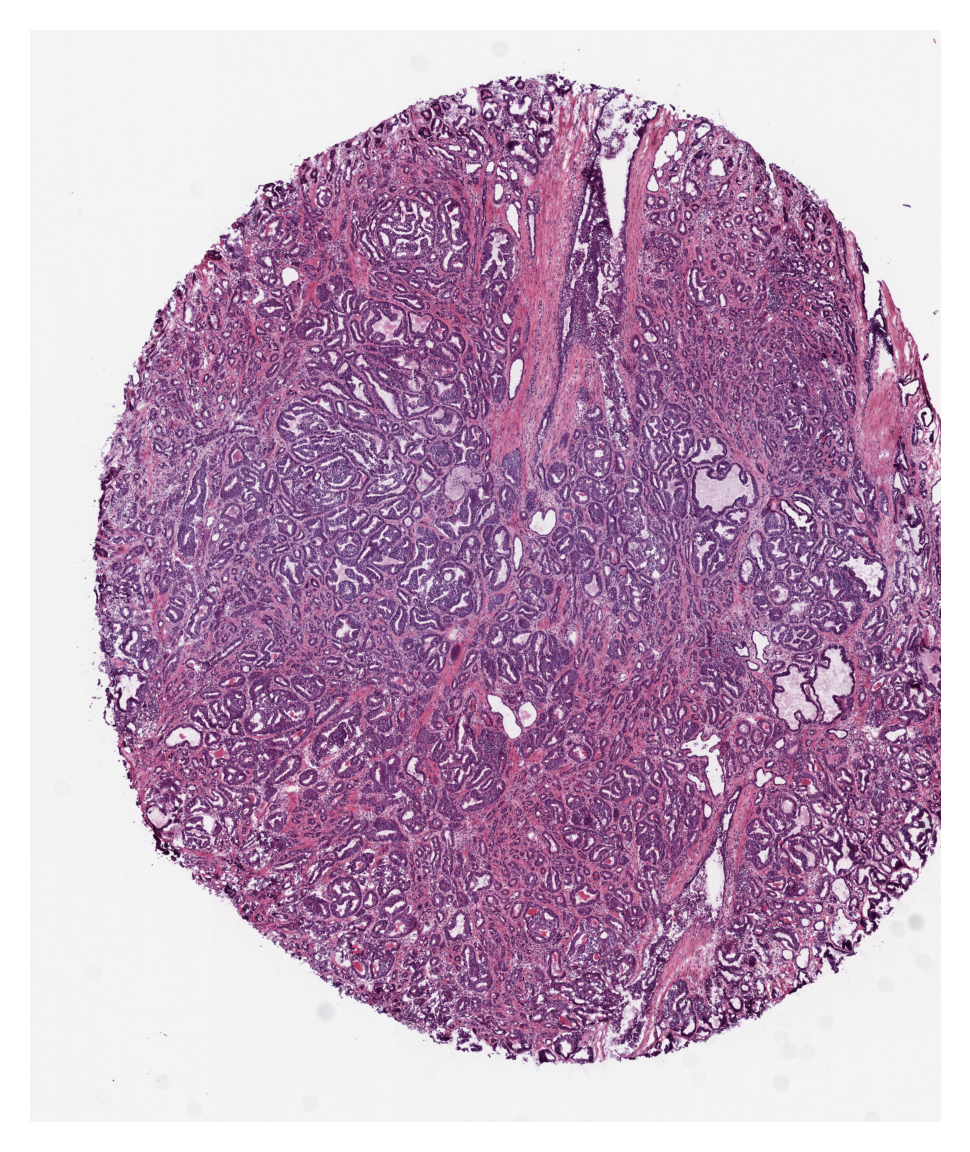

Identifiers successfully aligned with cluster labels.


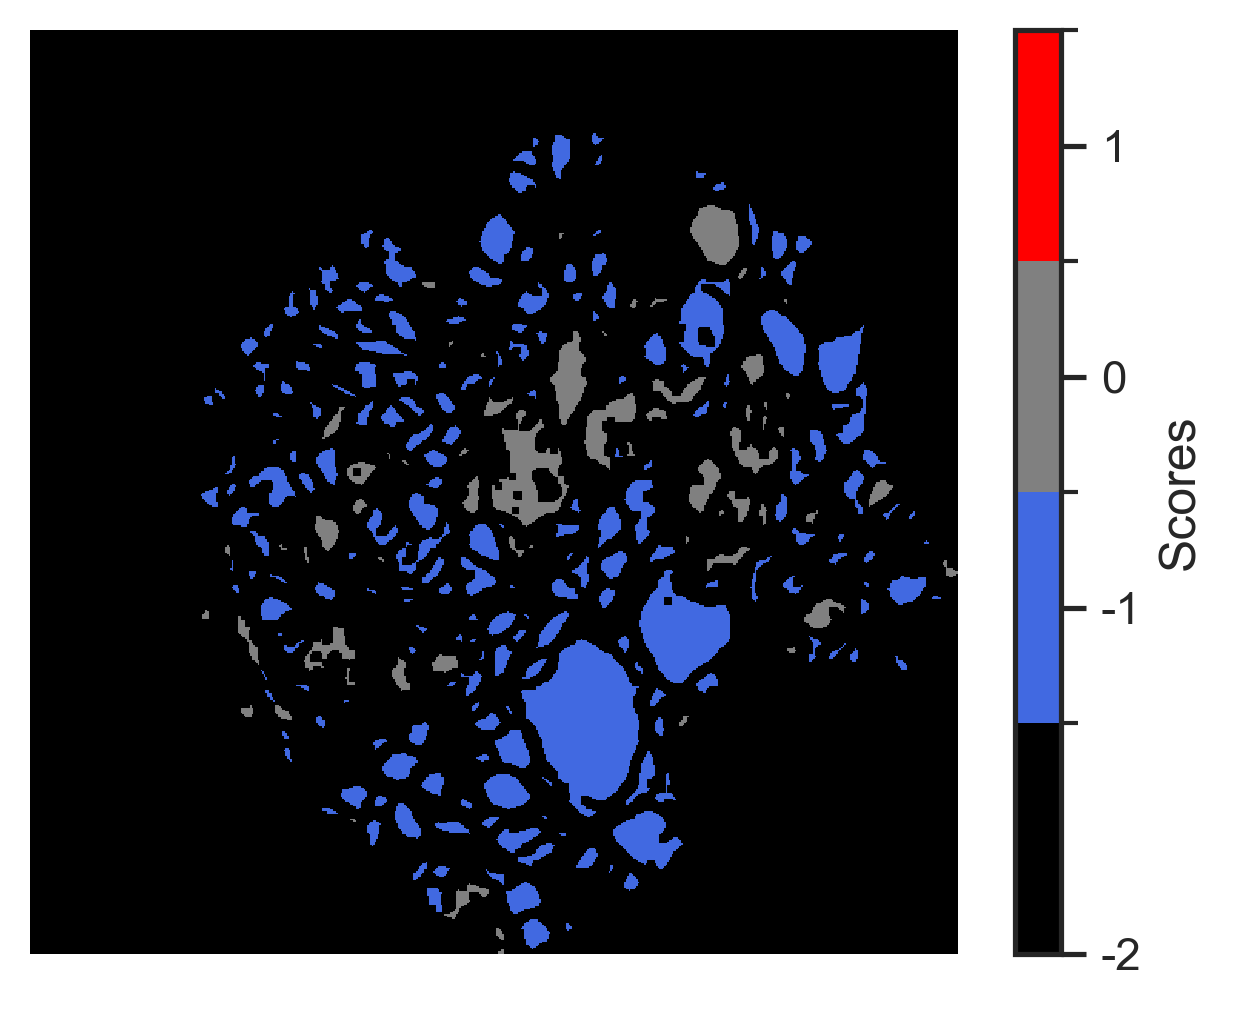

/Volumes/Elements/BDI/datasets/ICGCC/images/svs/TB09.0817_V6_05.svs


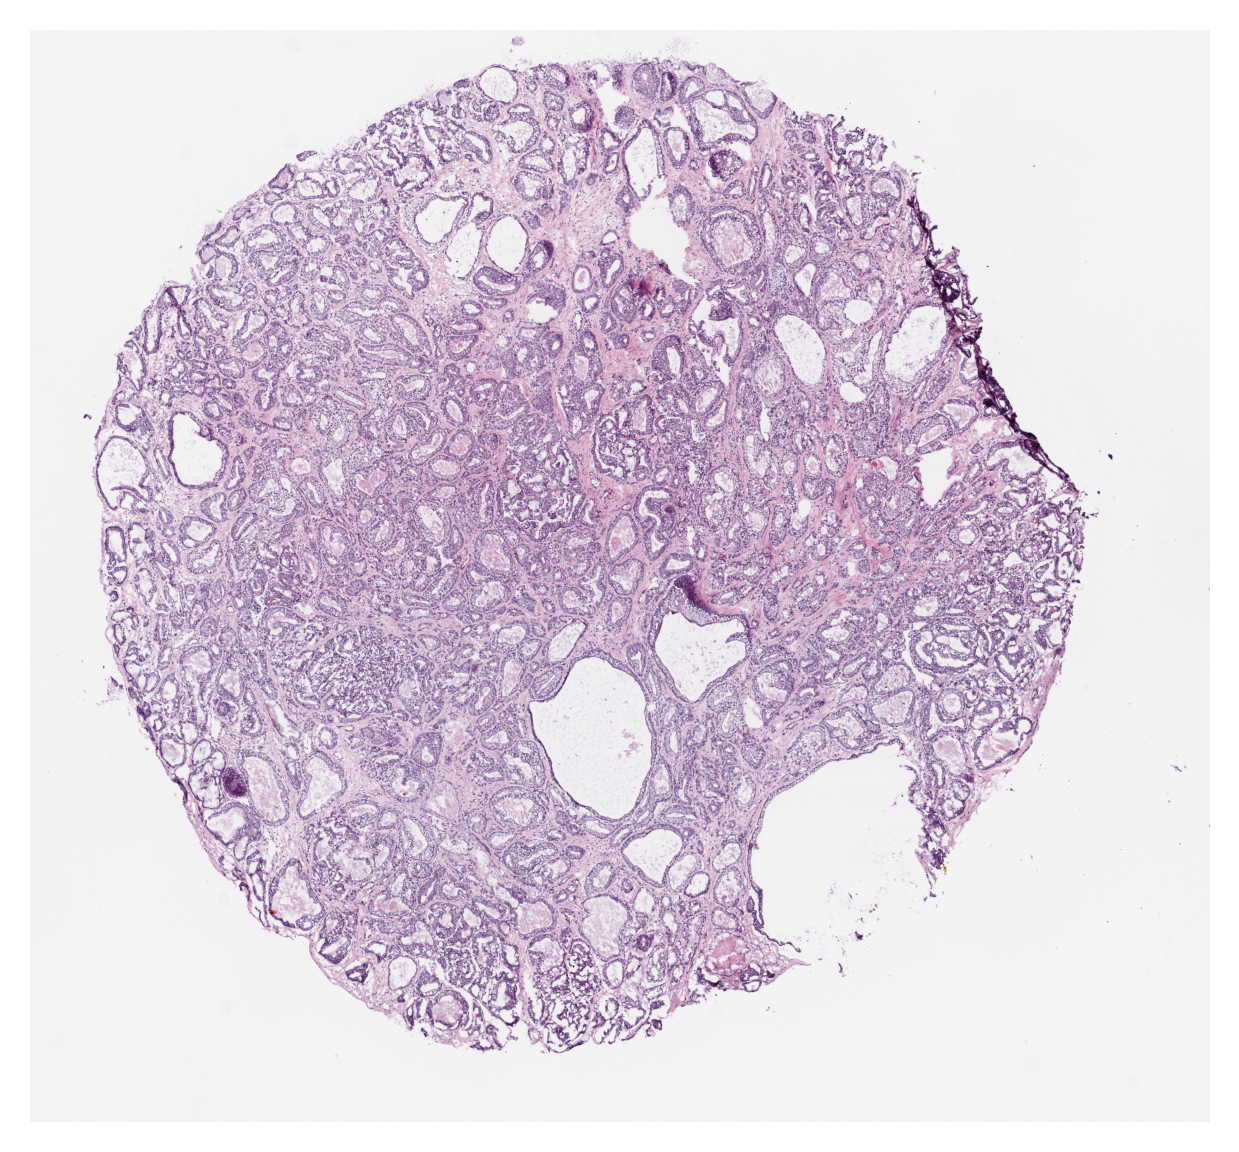

In [241]:
##########
## MAIN ##
##########

## EMT
visualise_scores('TCGA-V1-A8WV-01A_1.svs', 'tcga-oct', 'model_vit_tcgaoct_raw_FTL_0', 'EMT.GAIN', '/Volumes/Elements/BDI/datasets/TCGA/images/svs') # Positive
visualise_scores('TCGA-EJ-7218-01B_1.svs', 'tcga-oct', 'model_vit_tcgaoct_raw_FTL_0', 'EMT.GAIN', '/Volumes/Elements/BDI/datasets/TCGA/images/svs') # Negative

## BCR
visualise_scores('TB11.2230_V2_12.svs', 'icgc-c', 'model_vit_icgcc_raw_FTL_0', 'relapse', '/Volumes/Elements/BDI/datasets/ICGCC/images/svs') # Positive
visualise_scores('TB09.0817_V6_05.svs', 'icgc-c', 'model_vit_icgcc_raw_FTL_0', 'relapse', '/Volumes/Elements/BDI/datasets/ICGCC/images/svs') # Negative
# visualise_scores('TB11.2230_V2_13.svs', 'icgc-c', 'model_vit_icgcc_raw_FTL_0', 'relapse', '/Volumes/Elements/BDI/datasets/ICGCC/images/svs') # Positive
# visualise_scores('TB11.2230_V2_11.svs', 'icgc-c', 'model_vit_icgcc_raw_FTL_0', 'relapse', '/Volumes/Elements/BDI/datasets/ICGCC/images/svs') # Positive

## BCR other examples 
# visualise_scores('TB11.2230_V16_06.svs', 'icgc-c', 'model_vit_icgcc_raw_FTL_0', 'relapse', '/Volumes/Elements/BDI/datasets/ICGCC/images/svs') # Positive
# visualise_scores('TB13.1546_V1_03.svs', 'icgc-c', 'model_vit_icgcc_raw_FTL_0', 'relapse', '/Volumes/Elements/BDI/datasets/ICGCC/images/svs') # Positive
# visualise_scores('TB11.2230_V16_04.svs', 'icgc-c', 'model_vit_icgcc_raw_FTL_0', 'relapse', '/Volumes/Elements/BDI/datasets/ICGCC/images/svs') # Positive
# visualise_scores('TB12.1231_V11_03.svs', 'icgc-c', 'model_vit_icgcc_raw_FTL_0', 'relapse')
# visualise_scores('TB11.0598_V2_01.svs', 'icgc-c', 'model_vit_icgcc_raw_FTL_0', 'relapse')

#
###